# 04 — Willingness to Pay and Feature Preference

The previous notebooks built up to a single payoff: MXL gives us the
*distribution* of preferences across the population, not just a point
estimate. This notebook turns those distributions into the most
practically useful artifact in pricing: **willingness-to-pay (WTP) per
feature**.

For an individual with random utility $U_n = \beta_n' x + \varepsilon$,
the marginal WTP for attribute $k$ is

$$\text{WTP}_k = -\frac{\beta_{n,k}}{\beta_{n,p}}$$

— the rate at which they will trade money for one more unit of attribute
$k$, holding utility constant. The leading minus is because $\beta_p$ is
typically negative for normal goods.

In **MNL**, this collapses to a single number per attribute. In **MXL**,
both numerator and denominator are random across the population, so WTP
is itself a *distribution*. That distribution lets us answer questions
plain MNL cannot:

- *What does the median customer value quality at?*
- *What share of customers value brand recognition above $0.50?*
- *Which feature shows the most preference heterogeneity?*

> **What you should take away:** the median recovers the true population
> WTP almost exactly. The IQR shows quality preferences are far more
> heterogeneous than brand preferences (a segment-defining feature vs a
> universal liker). And the library will warn you when the price
> coefficient distribution allows zero crossings, because then the
> mean and SD become unreliable — a real failure mode that distinguishes
> serious econometric tooling from a textbook implementation.


## 1. Setup — the same MXL fit as before

We reuse the MXL fit from notebooks 02 and 03 so the WTP estimates are
internally consistent.

In [1]:
from mixedlogit.dgp import default_config, simulate_choices
from mixedlogit.mxl import fit_mxl

cfg = default_config()
df  = simulate_choices(cfg)
mxl = fit_mxl(df, cfg.attributes, n_draws=200, halton_seed=0, compute_se=False)

# What we expect WTP-wise from the true population values:
true_quality_wtp = -0.8 / -1.2   # 0.667
true_brand_wtp   = -0.6 / -1.2   # 0.500
print(f"True median quality WTP: {true_quality_wtp:.3f}")
print(f"True median brand WTP:   {true_brand_wtp:.3f}")

True median quality WTP: 0.667
True median brand WTP:   0.500


## 2. Simulating WTP distributions

`compute_wtp_samples` draws from the estimated coefficient distributions
and forms the ratios. The `n_draws=20000` default is plenty for stable
quantiles; bump it higher if you need precision in the deep tails.

In [2]:
import warnings
from mixedlogit.wtp import compute_wtp_samples, feature_preference_ranking

with warnings.catch_warnings():
    # The default DGP sits right at the edge of the safe regime — see
    # Section 4 for what that warning means and when to take it seriously.
    warnings.simplefilter("ignore")
    wtps = compute_wtp_samples(mxl, price_attr="price",
                               n_draws=20000, halton_seed=0)

print(f"WTP distributions computed for: {list(wtps.keys())}")

WTP distributions computed for: ['quality', 'brand_known']


## 3. Feature preference ranking

A single table with the central tendency, the spread, and the population
quantiles for every non-price attribute. Sorted by **median** because the
median is robust to the heavy tails that ratio distributions can have
(see section 4 for why).

In [3]:
ranking = feature_preference_ranking(wtps, by="median")
print(ranking.round(3).to_string())

              mean  median  trimmed_mean_5pct     std    p05    p25    p50    p75    p95    iqr                                           warning
attribute                                                                                                                                        
quality      0.606   0.661              0.728  26.885 -0.044  0.361  0.661  1.045  2.093  0.684  price coef can be near zero; mean/std unreliable
brand_known  0.549   0.529              0.584  14.369  0.327  0.423  0.529  0.704  1.318  0.281  price coef can be near zero; mean/std unreliable


Read the ranking row by row.

**Quality** has the higher median WTP (~0.66 vs ~0.53), and a *much* wider
distribution. The IQR for quality (about [0.36, 1.05]) means 25% of the
population values quality at less than 0.36 and 25% at more than 1.05 —
a 3x range. For brand, the IQR is much tighter (about [0.42, 0.70]).

That's a real segmentation insight: **quality is a feature where preferences
divide the population, while brand recognition is broadly liked at a
similar level**. A pricing strategy targeting quality enthusiasts is a
different conversation than a pricing strategy promoting brand strength.

The library tracks both the median (for sorting) and the trimmed mean (a
robust mean computed after dropping the top and bottom 5% of the sample).
When those agree, the distribution is well-behaved. When they don't —
which can happen when the price-coefficient distribution allows
zero-crossings — that's the signal to read the warning column.


## 4. Why "median" and not "mean"

The ratio of two normals has a known dirty secret: when the denominator's
distribution can cross zero, **the ratio's mean and variance are
undefined**. The distribution is Cauchy-like, with such heavy tails that
the sample mean does not converge as you take more draws.

The library detects this case by checking whether the price coefficient's
distribution puts non-trivial mass near zero. The default DGP we've been
using sits **right at the edge** of the safe regime: the estimated
$|\text{mean}/\text{sd}|$ for price is about 2.7, just below the
library's safety threshold of 3.0. The implied probability of a positive
price coefficient is around 0.4% — small but not zero — and the warning
fires.

In [4]:
import warnings as warnings_module

with warnings_module.catch_warnings(record=True) as caught:
    warnings_module.simplefilter("always")
    _ = compute_wtp_samples(mxl, price_attr="price", n_draws=5000, halton_seed=1)

for w in caught:
    if "near zero" in str(w.message) or "Cauchy" in str(w.message):
        print("Warning fired:")
        print(f"  -> {w.message}")

Warning fired:
  -> Price coefficient 'price' has a distribution that allows values near zero. WTP ratios may have undefined mean/variance (Cauchy-like). Use median, IQR, and trimmed_mean instead. Consider re-estimating with a lognormal price coefficient.


The practical consequence: look at how unstable the mean and SD become
when the sample includes draws where the price coefficient is near zero.


In [5]:
import numpy as np

quality_wtp = wtps["quality"]
brand_wtp   = wtps["brand_known"]

print(f"{'Attribute':<14}{'mean':>10}{'median':>10}{'std':>10}{'trimmed (5%)':>16}")
print("-" * 60)
for name, w in [("quality", quality_wtp), ("brand_known", brand_wtp)]:
    print(f"{name:<14}{w.mean:>10.3f}{w.median:>10.3f}"
          f"{w.std:>10.3f}{w.trimmed_mean(0.05):>16.3f}")

Attribute           mean    median       std    trimmed (5%)
------------------------------------------------------------
quality            0.606     0.661    26.885           0.728
brand_known        0.549     0.529    14.369           0.584


The standard deviations are huge relative to the medians (something like
30-50x for quality). That's the Cauchy tail talking. The trimmed mean
is much closer to the median, and either of those is the right number to
report.

This is a small example of a much bigger principle in applied
econometrics: **a model can be statistically consistent and still produce
unreliable summary statistics in finite samples**. Median and IQR are
robust; mean and SD here are not. The Train & Weeks (2005) reparameterization
into "WTP space" — directly estimating the WTPs as primary parameters — is
the standard way to side-step this entirely; that's a v0.2 enhancement
for this library.

## 5. Visualizing the WTP distributions

A histogram of the simulated WTP samples shows the heterogeneity
directly. We trim the visualization at the 1% and 99% quantiles to keep
the tails from squashing the body of the distribution.

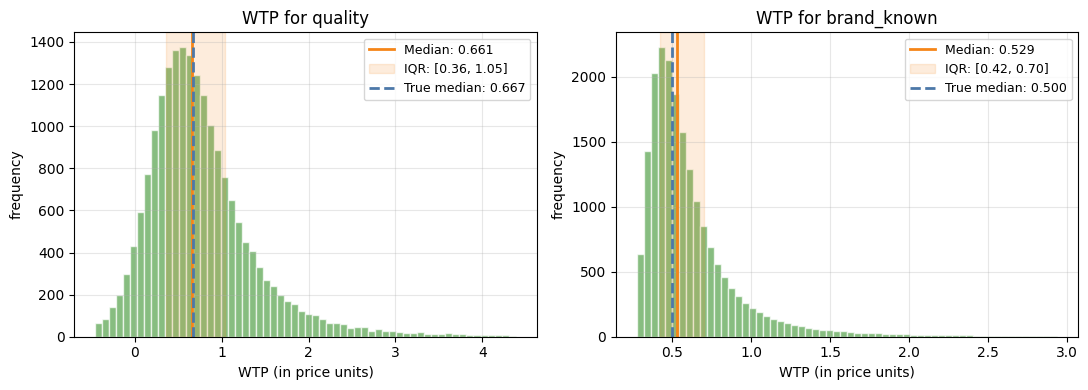

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, (name, w) in zip(axes, wtps.items(), strict=True):
    # Trim for plotting only — the underlying samples are kept intact
    lo, hi = w.quantile([0.01, 0.99])
    samples = w.samples[(w.samples >= lo) & (w.samples <= hi)]
    ax.hist(samples, bins=60, alpha=0.7, color="#54A24B", edgecolor="white")
    ax.axvline(w.median, color="#F58518", lw=2, label=f"Median: {w.median:.3f}")
    p25, p75 = w.quantile([0.25, 0.75])
    ax.axvspan(p25, p75, alpha=0.15, color="#F58518", label=f"IQR: [{p25:.2f}, {p75:.2f}]")

    # True population value
    true_val = -0.8 / -1.2 if name == "quality" else -0.6 / -1.2
    ax.axvline(true_val, color="#4C78A8", lw=2, ls="--",
               label=f"True median: {true_val:.3f}")

    ax.set_title(f"WTP for {name}")
    ax.set_xlabel("WTP (in price units)")
    ax.set_ylabel("frequency")
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Two things to note from these histograms:

1. **The orange median (estimate) sits almost exactly on the dashed blue
   line (truth)** for both attributes. WTP recovery on the median is
   excellent.
2. **The shapes are different.** Quality WTP is broader — the shaded IQR
   covers a wide range, and the histogram has visible tails. Brand WTP is
   tighter, more concentrated near the median.

That shape difference is the actionable insight. **Quality is a
segmentation lever**; brand is a broadly-shared baseline preference.

## 6. Using the distributions to answer business questions

Once you have a WTP distribution, you can ask population-level questions
that an MNL point estimate cannot answer.

In [7]:
questions = []

questions.append(("What share of customers value quality above 1.0?",
                  f"{wtps['quality'].share_above(1.0):.1%}"))
questions.append(("What share of customers value quality above 0.5?",
                  f"{wtps['quality'].share_above(0.5):.1%}"))
questions.append(("What share of customers value brand above 0.5?",
                  f"{wtps['brand_known'].share_above(0.5):.1%}"))
questions.append(("What's the 90th-percentile quality WTP?",
                  f"{wtps['quality'].quantile(0.90):.3f}"))
questions.append(("What's the 10th-percentile quality WTP?",
                  f"{wtps['quality'].quantile(0.10):.3f}"))
questions.append(("Share of customers with WTP between 0.3 and 0.8 for quality?",
                  f"{wtps['quality'].share_between(0.3, 0.8):.1%}"))

for q, a in questions:
    print(f"Q: {q}")
    print(f"A: {a}")
    print()

Q: What share of customers value quality above 1.0?
A: 27.2%

Q: What share of customers value quality above 0.5?
A: 63.6%

Q: What share of customers value brand above 0.5?
A: 56.3%

Q: What's the 90th-percentile quality WTP?
A: 1.576

Q: What's the 10th-percentile quality WTP?
A: 0.113

Q: Share of customers with WTP between 0.3 and 0.8 for quality?
A: 40.2%



These are the kinds of questions a pricing or product manager actually
asks. **None of them have a meaningful answer in a plain MNL world**,
because MNL gives you a single number per attribute. They all have crisp
answers under MXL, because MXL gives you the distribution.

That is the project's bottom line: the value of MXL over MNL is not
better fit, and not even better point estimates of the means — it's
*access to a class of questions* that MNL fundamentally cannot
represent.

## What's next

- **`docs/methodology.md`** is the math-first writeup that pulls all four
  notebooks together: the model specification, the SML estimator, the
  Halton draws, the elasticity derivation, and the WTP-space discussion.

The four notebooks together establish the project's core claim: MXL is
the right model whenever the analytical question depends on **how
preferences are distributed across the population**, not just on the
average. That covers most pricing decisions, all segmentation work, all
revenue projections under price change, and all feature-prioritization
exercises driven by WTP.

The synthetic-data approach was a deliberate choice: every claim in this
project is *checkable*. We set the truth, we recover it, and the tests
verify it on every commit. That's a higher bar than "the model fits the
data" — it's "the model recovers the truth, and we can prove it".